In [1]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning, BinningProcess
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

master = pd.read_parquet('../data/processed/master_table.parquet')

# 需要剔除的列：客户ID、标签，不能放进特征集
DROP_COLS = ['SK_ID_CURR', 'TARGET']
X = master.drop(columns=DROP_COLS)
y = master['TARGET']

print(f"Shape: {X.shape}")
print(f"Target rate: {y.mean():.3f}")

Shape: (307511, 164)
Target rate: 0.081


In [5]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning, BinningProcess
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

master = pd.read_parquet('../data/processed/master_table.parquet')

# 需要剔除的列：客户ID、标签，不能放进特征集
DROP_COLS = ['SK_ID_CURR', 'TARGET']
X = master.drop(columns=DROP_COLS)
y = master['TARGET']

print(f"Shape: {X.shape}")
print(f"Target rate: {y.mean():.3f}")

Shape: (307511, 164)
Target rate: 0.081


In [6]:
# 原本计划使用审批日期划分时间外样本；HomeCredit数据集缺少真实申请时间，无法按时间切分
# 因此采用分层随机划分：训练集80%，随机留出测试集20%

from sklearn.model_selection import train_test_split

X_train, X_oot, y_train, y_oot = train_test_split(
    X, y,
    test_size=0.2,        # 20%划分为测试集，80%训练集
    random_state=42,      # 随机种子，固定划分结果，保证代码复现
    stratify=y            # 分层抽样！保证训练集、测试集坏账比例和全集保持一致
)

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"Holdout:   {X_oot.shape},   default rate: {y_oot.mean():.3f}")

Train: (246008, 164), default rate: 0.081
Holdout:   (61503, 164),   default rate: 0.081


In [7]:
# 类别特征预处理，用于后续IV计算
# 类别映射规则只能基于训练集生成，保存映射文件，保证留出集编码方式和训练集完全统一
# 防止测试集出现训练集未见过的类别，避免预测不一致

X_train_enc = X_train.copy()
X_oot_enc   = X_oot.copy()

cat_cols = X_train.select_dtypes(include='object').columns.tolist()

category_maps = {}

for col in cat_cols:
    cats = sorted(X_train[col].fillna('Missing').unique().tolist())
    category_maps[col] = cats
    
    X_train_enc[col] = pd.Categorical(
        X_train[col].fillna('Missing'), categories=cats
    ).codes.astype(float)
    
    # 留出集：使用【训练集定义好的类别】编码，保证规则一致
    X_oot_enc[col] = pd.Categorical(
        X_oot[col].fillna('Missing'), categories=cats
    ).codes.astype(float)

# 将分类特征的类别清单保存为json文件，线上预测时复用这套映射规则
with open('../models/category_maps.json', 'w') as f:
    json.dump(category_maps, f)

print(f"Encoded {len(cat_cols)} categorical columns, saved category_maps.json")
print(X_train_enc[cat_cols[:3]].dtypes) # 校验：确认编码后转为浮点型

Encoded 16 categorical columns, saved category_maps.json
NAME_CONTRACT_TYPE    float64
CODE_GENDER           float64
FLAG_OWN_CAR          float64
dtype: object


In [9]:
def calculate_iv(X, y, features, categorical_cols):
    iv_results = []
    for col in features:
        try:
            x_col = X[col].astype('float64')
            # 重点：分类特征即使编码成数字，依然告诉工具按分类处理，不要当成连续变量分箱
            dtype = 'categorical' if col in categorical_cols else 'numerical'
            ob = OptimalBinning(name=col, dtype=dtype, solver='cp')
            ob.fit(x_col.values, y.values)
            binning_table = ob.binning_table.build()
            iv = binning_table['IV'].iloc[-1]
            iv_results.append({'feature': col, 'iv': round(iv, 4)})
        except Exception as e:
            print(f"ERROR on {col}: {e}")
            # 异常特征IV赋值0，代表无预测能力
            iv_results.append({'feature': col, 'iv': 0.0})
    return pd.DataFrame(iv_results).sort_values('iv', ascending=False)

# 分类特征按类别处理，不能把编码后的数字当作连续数值
iv_df = calculate_iv(X_train_enc, y_train, X_train_enc.columns.tolist(), cat_cols)
print(iv_df.head(10))

                     feature      iv
41              EXT_SOURCE_3  0.3353
40              EXT_SOURCE_2  0.3190
39              EXT_SOURCE_1  0.1480
127  bureau_days_credit_mean  0.1233
16             DAYS_EMPLOYED  0.1158
8            AMT_GOODS_PRICE  0.0925
15                DAYS_BIRTH  0.0903
26           OCCUPATION_TYPE  0.0784
38         ORGANIZATION_TYPE  0.0735
147   inst_late_payment_rate  0.0651


In [23]:
# ==============================================================================
# 实验1：分箱方式对比实验
# 实验目的：对比最优分箱OptimalBinning 和 等频10箱(qcut)对Top10核心特征IV及同一组连续特征模型效果的影响
# 控制变量：数据集、训练/随机留出划分、随机种子、LR参数固定；唯一变量：分箱策略
# 重要说明：pd.qcut仅适用于连续数值特征，分类特征不纳入等频分箱对比
# 实验局限性声明：特征子集基于Optbinning全特征IV筛选得到，结论仅适用于高IV核心特征
# ==============================================================================

top10_feats = iv_df.head(10)["feature"].tolist()
print("="*60)
print(f"筛选得到最优分箱下IV排名前10特征：")
for idx, fname in enumerate(top10_feats):
    print(f"{idx+1:2d}. {fname}")
print("="*60)

X_train_exp = X_train_enc[top10_feats].copy()
X_oot_exp = X_oot_enc[top10_feats].copy()
y_train_exp = y_train.copy()
y_oot_exp = y_oot.copy()

all_cat_feats_exp = [col for col in top10_feats if col in cat_cols]
cont_feats_exp = [col for col in top10_feats if col not in cat_cols]
print(f"\n分类特征（不参与等频分箱对比）：{all_cat_feats_exp}")
print(f"参与等频分箱对比的连续特征：{cont_feats_exp}")

筛选得到最优分箱下IV排名前10特征：
 1. EXT_SOURCE_3
 2. EXT_SOURCE_2
 3. EXT_SOURCE_1
 4. bureau_days_credit_mean
 5. DAYS_EMPLOYED
 6. AMT_GOODS_PRICE
 7. DAYS_BIRTH
 8. OCCUPATION_TYPE
 9. ORGANIZATION_TYPE
10. inst_late_payment_rate

分类特征（不参与等频分箱对比）：['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
参与等频分箱对比的连续特征：['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'bureau_days_credit_mean', 'DAYS_EMPLOYED', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'inst_late_payment_rate']


In [3]:
def qcut_woe_iv_transform(df_train, df_test, feat_list, target, q_bins=10):
    eps = 1e-8
    total_good_train = (target == 0).sum()
    total_bad_train = (target == 1).sum()
    
    train_woe_df = pd.DataFrame()
    oot_woe_df = pd.DataFrame()
    iv_result_dict = {}

    for col in feat_list:
        train_data = df_train[col]
        oot_data = df_test[col]

        
        # =========区分正常值 和 缺失值========
        train_not_null = train_data.notna()

        train_valid = train_data[train_not_null]
        train_y_valid = target[train_not_null]
        train_null_flag = ~train_not_null

        bins = pd.qcut(train_valid, q=q_bins, duplicates="drop", retbins=True)[1]

        bins = np.unique(bins)

        if len(bins) < 2:
            print(f"警告：{col} 分箱区间不足，跳过")
            iv_result_dict[col] = 0
            continue
        

        # ========= 有效数值部分分箱 =========
        train_segment = pd.cut(train_valid, bins=bins, include_lowest=True)

        df_seg = pd.DataFrame({"seg": train_segment, "y": train_y_valid})

# ========= 合并缺失样本分组 =========
        df_null = pd.DataFrame({"seg": "MISSING", "y": target[train_null_flag]})

        df_all = pd.concat([df_seg, df_null])

      

        group = df_all.groupby("seg")["y"].agg(bad="sum", total="count")
        group["good"] = group["total"] - group["bad"]
        group["p_bad"] = group["bad"] / (total_bad_train + eps)
        group["p_good"] = group["good"] / (total_good_train + eps)
        group["woe"] = np.log(group["p_good"] / group["p_bad"])
        group["iv_item"] = (group["p_good"] - group["p_bad"]) * group["woe"]
        iv_result_dict[col] = group["iv_item"].sum()
        woe_map = group["woe"].to_dict()

        # =========训练集WOE赋值========
        tmp_train = pd.Series(np.nan, index=train_data.index)
        tmp_train.loc[train_not_null] = pd.cut(train_valid, bins=bins, include_lowest=True).map(woe_map)
        if "MISSING" in woe_map:
            tmp_train.loc[train_null_flag] = woe_map["MISSING"]
        else:
            tmp_train.loc[train_null_flag] = 0.0
        train_woe_df[col] = tmp_train

        # =========留出集WOE赋值========
        oot_not_null = oot_data.notna()
        oot_null_flag = ~oot_not_null
        temp_woe = pd.Series(np.nan, index=oot_data.index)

        oot_valid = oot_data[oot_not_null]
        oot_seg = pd.cut(oot_valid, bins=bins, include_lowest=True)
        temp_woe.loc[oot_not_null] = oot_seg.map(woe_map)
        # 留出集原始缺失值填充
        if "MISSING" in woe_map:
            temp_woe.loc[oot_null_flag] = woe_map["MISSING"]
        else:
            temp_woe.loc[oot_null_flag] = 0.0

        # 处理超出边界域外样本
        woe_keys = [k for k in woe_map.keys() if k != "MISSING"]
        if len(woe_keys)>=2:
            first_woe = woe_map[woe_keys[0]]
            last_woe = woe_map[woe_keys[-1]]
            min_bin = bins[0]
            max_bin = bins[-1]
            temp_woe.loc[oot_data < min_bin] = first_woe
            temp_woe.loc[oot_data > max_bin] = last_woe
        oot_woe_df[col] = temp_woe

    return train_woe_df, oot_woe_df, iv_result_dict

In [4]:
## ----------------------工具函数2：Optbinning最优分箱WOE转换（复用前面逻辑）
def optbin_woe_transform(df_train, df_test, feat_list, target, cat_feature_list):
    """最优分箱，生成WOE数据集，保存分箱器用于留出集转换，输出IV字典"""
    train_woe_df = pd.DataFrame()
    oot_woe_df = pd.DataFrame()
    iv_result_dict = {}
    bin_store = {}

    for col in feat_list:
        x_train_col = df_train[col].astype("float64")
        dtype = "categorical" if col in cat_feature_list else "numerical"
        ob = OptimalBinning(name=col, dtype=dtype, solver="cp")
        ob.fit(x_train_col.values, target.values)
        train_woe_df[col] = ob.transform(x_train_col.values, metric="woe")
        oot_woe_df[col] = ob.transform(df_test[col].values, metric="woe")
        iv_val = ob.binning_table.build()["IV"].iloc[-1]
        iv_result_dict[col] = iv_val
        bin_store[col] = ob
    return train_woe_df, oot_woe_df, iv_result_dict, bin_store

In [5]:
## ----------------------工具函数3：模型评估（AUC、KS）
def model_evaluate_lr(Xtr, ytr, Xval, yval, random_seed=42):
    """固定参数训练LR，输出训练集、验证集AUC、KS"""
    def ks_calc(y_true, pred):
        tmp = pd.DataFrame({"y": y_true, "pred": pred})
        tmp = tmp.sort_values("pred")
        tmp["cum_bad"] = tmp["y"].cumsum() / tmp["y"].sum()
        tmp["cum_good"] = (1-tmp["y"]).cumsum() / (1-tmp["y"]).sum()
        ks = np.max(np.abs(tmp["cum_bad"] - tmp["cum_good"]))
        return ks
    
    lr = LogisticRegression(random_state=random_seed, C=1.0, max_iter=800)
    lr.fit(Xtr, ytr)
    pred_tr = lr.predict_proba(Xtr)[:,1]
    auc_tr = roc_auc_score(ytr, pred_tr)
    ks_tr = ks_calc(ytr, pred_tr)
    pred_val = lr.predict_proba(Xval)[:,1]
    auc_val = roc_auc_score(yval, pred_val)
    ks_val = ks_calc(yval, pred_val)
    return {
        "train_auc":auc_tr, "train_ks":ks_tr,
        "oot_auc":auc_val, "oot_ks":ks_val
    }

In [51]:
# ======================正式执行两套分箱实验 ======================
# 实验组A：OptimalBinning最优分箱（先对Top10拟合；IV和模型对比均取同一组连续特征）
Xtrain_woe_opt, Xoot_woe_opt, iv_opt_dict, bin_save = optbin_woe_transform(
    X_train_exp, X_oot_exp, top10_feats, y_train_exp, cat_cols
)

# 实验组B：等频10箱分箱（仅使用连续特征！！）
Xtrain_woe_qcut, Xoot_woe_qcut, iv_qcut_dict = qcut_woe_iv_transform(
    X_train_exp, X_oot_exp, cont_feats_exp, y_train_exp, q_bins=10
)

iv_compare_table = pd.DataFrame({
    "feature": cont_feats_exp,
    "iv_optbin": [iv_opt_dict[f] for f in cont_feats_exp],
    "iv_qcut10": [iv_qcut_dict[f] for f in cont_feats_exp]
})
iv_compare_table["iv_diff(opt-qcut)"] = iv_compare_table["iv_optbin"] - iv_compare_table["iv_qcut10"]
iv_compare_table = iv_compare_table.round(4)

print("\n【连续特征单特征IV对比表】")
print(iv_compare_table)
print(f"\n参与对比的连续特征IV总和：")
print(f"最优分箱 IV总和 = {sum(iv_opt_dict[f] for f in cont_feats_exp):.4f}")
print(f"等频10箱 IV总和 = {sum(iv_qcut_dict.values()):.4f}")


【连续特征单特征IV对比表】
                   feature  iv_optbin  iv_qcut10  iv_diff(opt-qcut)
0             EXT_SOURCE_3     0.3353     0.3298             0.0056
1             EXT_SOURCE_2     0.3190     0.3032             0.0158
2             EXT_SOURCE_1     0.1480     0.1513            -0.0034
3  bureau_days_credit_mean     0.1233     0.1200             0.0033
4            DAYS_EMPLOYED     0.1158     0.1008             0.0150
5          AMT_GOODS_PRICE     0.0925     0.0914             0.0011
6               DAYS_BIRTH     0.0903     0.0868             0.0035
7   inst_late_payment_rate     0.0651     0.0630             0.0021

参与对比的连续特征IV总和：
最优分箱 IV总和 = 1.2893
等频10箱 IV总和 = 1.2464


In [59]:
# 关键！两组模型统一只使用同一组【8个连续特征 cont_feats_exp】，保证特征集一致，公平对比
result_opt = model_evaluate_lr(Xtrain_woe_opt[cont_feats_exp], y_train_exp, 
                               Xoot_woe_opt[cont_feats_exp], y_oot_exp)
result_qcut = model_evaluate_lr(Xtrain_woe_qcut, y_train_exp, 
                                Xoot_woe_qcut, y_oot_exp)

print("\n" + "="*60)
print("【模型效果对比】")
res_df = pd.DataFrame({
    "指标":["Train AUC","Train KS","Holdout AUC","Holdout KS"],
    "OptimalBinning最优分箱":[
        result_opt["train_auc"], result_opt["train_ks"],
        result_opt["oot_auc"], result_opt["oot_ks"]
    ],
    "等频10箱 qcut":[
        result_qcut["train_auc"], result_qcut["train_ks"],
        result_qcut["oot_auc"], result_qcut["oot_ks"]
    ]
}).round(4)
print(res_df)


【模型效果对比】
          指标  OptimalBinning最优分箱  等频10箱 qcut
0  Train AUC              0.7389      0.7367
1   Train KS              0.3572      0.3561
2    Holdout AUC              0.7379      0.7382
3     Holdout KS              0.3525      0.3586


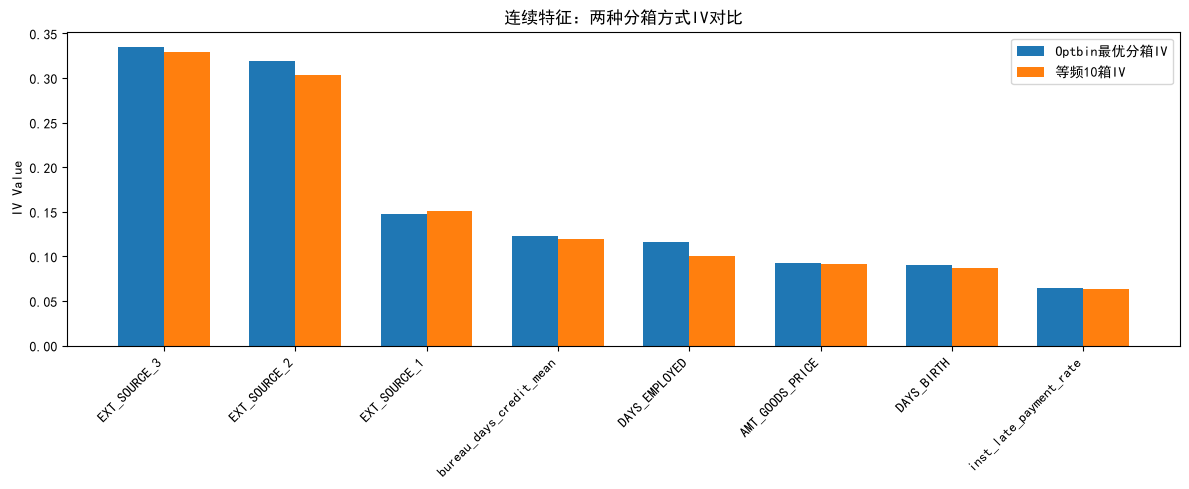

In [56]:
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方框

plt.figure(figsize=(12,5))
x = np.arange(len(cont_feats_exp))
width = 0.35

plt.bar(x-width/2, iv_compare_table["iv_optbin"], width, label="Optbin最优分箱IV")
plt.bar(x+width/2, iv_compare_table["iv_qcut10"], width, label="等频10箱IV")

plt.xticks(x, cont_feats_exp, rotation=45, ha="right")
plt.ylabel("IV Value")
plt.title("连续特征：两种分箱方式IV对比")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# 【实验局限性说明】
# 本实验简化设计：首先基于全特征OptimalBinning最优分箱结果计算IV，筛选IV排名前10核心特征作为实验对象；
# 考虑pd.qcut等频分箱仅适用于连续数值特征，分类特征（OCCUPATION_TYPE、ORGANIZATION_TYPE）不纳入本次对比。
# 局限性：特征筛选依赖最优分箱的IV结果，存在选择偏向；实验结论仅适用于高IV连续核心特征，弱特征、分类特征上两种分箱方案的差异不在本次验证范围内。

In [61]:
## 实验结论
#选取8项连续特征，控制变量对比OptimalBinning最优分箱与等频10分箱。IV指标显示最优分箱累计信息价值更高；训练集LR模型最优分箱表现更好，留出集两组模型性能十分接近。
#有监督最优分箱借助标签挖掘风险分界，信息留存更充分；无监督等频分箱规则简单，但容易损失特征信息。
#实操建议：评分卡开发优先使用OptimalBinning；样本较少、注重泛化稳定性时可考虑等频分箱作为备选。
#局限性：仅测试连续特征，数据集为公开数据集，特征筛选存在轻微选择偏倚。